# Market Screening and Stock Analysis

This notebook explores a wider basket of equities using return summaries, correlation views, moving-average checks, and single-name inspection cells.

It is best read as a broad stock-analysis workbook rather than a single linear study.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ticker = ["SPY","AFRM","SOFI","MBLY","HOOD","HIMS","GTLB","PLTR","ALGS","AMD","U","SIRI","WDAY","HUM","NIO","RIVN","FDX","BIDU","BIVI","TSLA","AMZN","MSFT","NVDA","META","GOOG","AAPL",]
stonks = yf.download(ticker, start = "2023-01-01", end = "2025-01-31")

[*********************100%***********************]  26 of 26 completed

26 Failed downloads:
['HUM', 'AFRM', 'ALGS', 'SOFI', 'NVDA', 'BIVI', 'WDAY', 'HOOD', 'GTLB', 'TSLA', 'HIMS', 'U', 'FDX', 'AAPL', 'GOOG', 'AMZN', 'SPY', 'AMD', 'NIO', 'BIDU', 'MSFT', 'PLTR', 'META', 'SIRI', 'MBLY', 'RIVN']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [3]:
close = stonks.loc[:, "Close"]

In [5]:
summary = ret.describe().T.loc[:,["mean","std"]]

In [4]:
ret = close.pct_change().dropna()

In [6]:
summary["mean"]=summary["mean"]*252
summary["std"]=summary["std"]*np.sqrt(252)

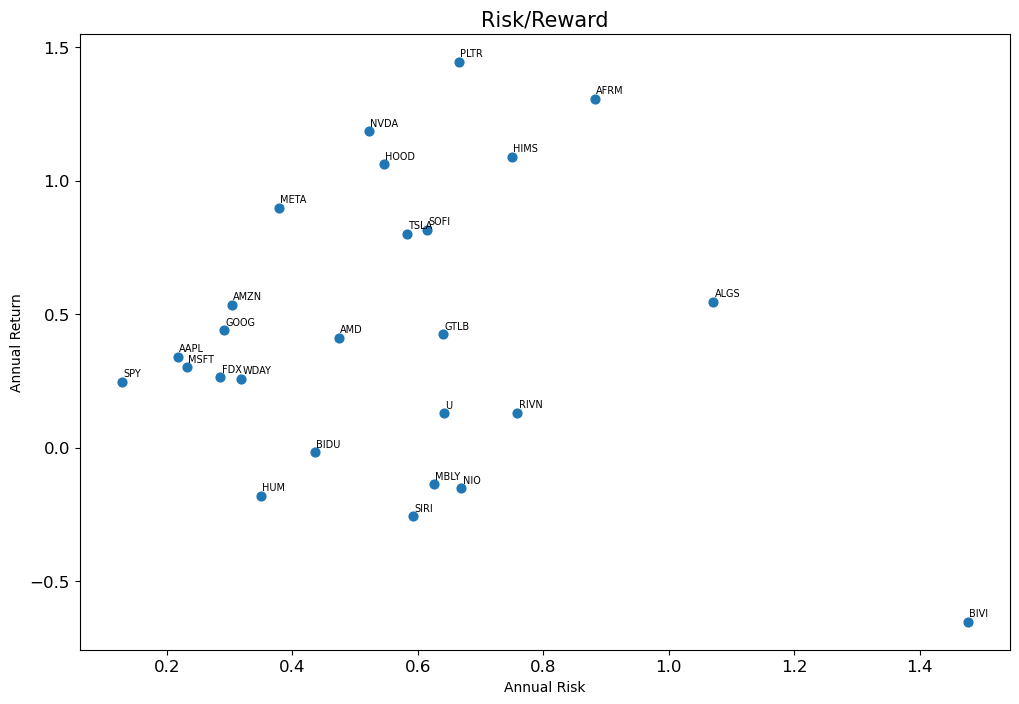

In [7]:
summary.plot.scatter(x='std',y='mean', figsize=(12,8), s=40, fontsize=12)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i,"std"]+0.002,summary.loc[i,"mean"]+0.02), size=7)
plt.xlabel("Annual Risk")
plt.ylabel("Annual Return")
plt.title("Risk/Reward", fontsize=15)
plt.show()

In [8]:
import seaborn as sns
plt.figure(figsize=(25, 10))

<Figure size 2500x1000 with 0 Axes>

<Figure size 2500x1000 with 0 Axes>

In [251]:
def correlation(tickers,start,end):
    df = yf.download(tickers, start = start, end = end)
    data = df.Close.copy()
    retu =np.log(data.pct_change()+1)
    retu.dropna(inplace=True)
    sns.set(font_scale=1)
    fig, ax = plt.subplots(figsize=(12, 7.5))
    sns.heatmap(retu.corr(), cmap ="Reds", annot=True, annot_kws={"size":12}, vmax=0.6)
    plt.show()

[*********************100%***********************]  7 of 7 completed


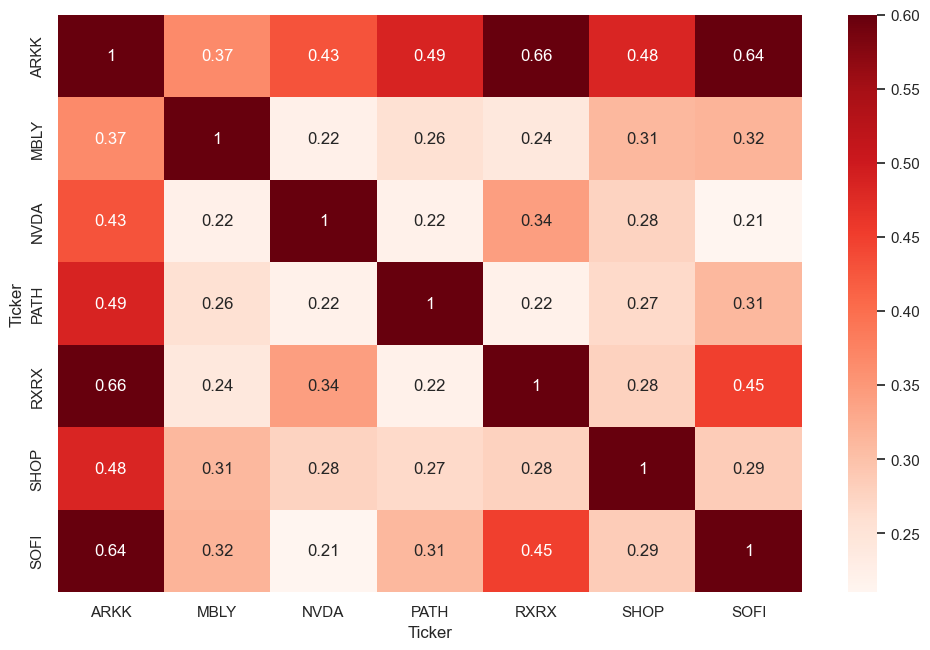

In [281]:
ab = ["MBLY",'SOFI','RXRX','PATH','ARKK','NVDA','SHOP']
correlation(ab, '2024-03-01', '2025-02-16')

In [235]:
# sns.set(font_scale=0.7)
# fig, ax = plt.subplots(figsize=(12, 7.5))
# sns.heatmap(ret.corr(), cmap ="Reds", annot=True, annot_kws={"size":7}, vmax=0.6)
# plt.show()

In [10]:
ticker1=["PLTR","AFRM","HOOD","HIMS"]
stonks1=yf.download(ticker1)

[*********************100%***********************]  4 of 4 completed


In [11]:
close1=stonks1.Close.copy()

In [12]:
close1["AFRM_SMA50"]=close1.AFRM.rolling(window=50).mean()

In [13]:
close1["HOOD_SMA50"]=close1.HOOD.rolling(window=50).mean().dropna()
close1["PLTR_SMA50"]=close1.PLTR.rolling(window=50).mean().dropna()
close1["HIMS_SMA50"]=close1.HIMS.rolling(window=50).mean().dropna()

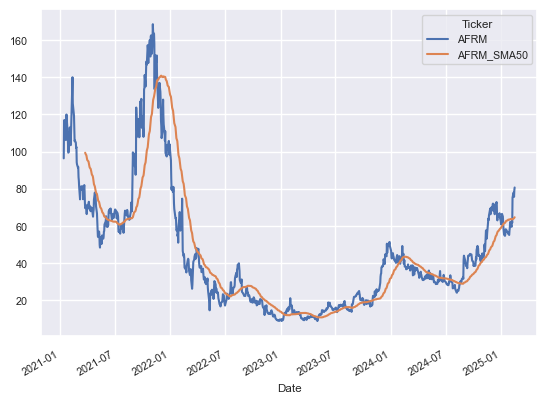

In [15]:
close1.loc[:,["AFRM","AFRM_SMA50"]].plot()
plt.show()

In [16]:
bivi =(yf.download("BIVI")).Close

[*********************100%***********************]  1 of 1 completed


In [17]:
bivi["d_returns"]=np.log(bivi.pct_change()+1)

In [18]:
bivi.dropna(inplace=True)

In [19]:
bivi["cumreturns"]=bivi.d_returns.cumsum().apply(np.exp)

In [20]:
bivi

Ticker,BIVI,d_returns,cumreturns
Date,,,
2020-09-21,97.500000,-0.024317,0.975976
2020-09-22,95.500000,-0.020726,0.955956
2020-09-23,93.000000,-0.026527,0.930931
2020-09-24,94.000000,0.010695,0.940941
2020-09-25,91.599998,-0.025864,0.916917
...,...,...,...
2025-02-10,1.860000,-0.031749,0.018619
2025-02-11,1.800000,-0.032790,0.018018
2025-02-12,1.730000,-0.039665,0.017317


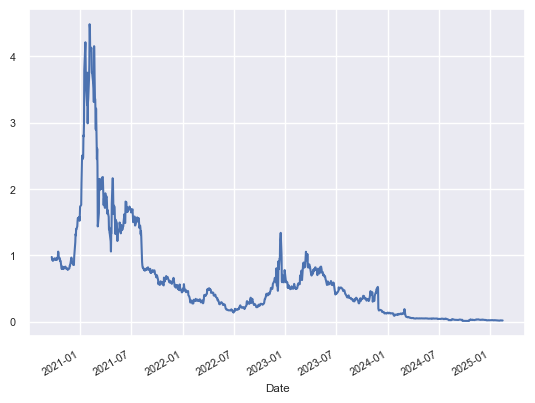

In [21]:
bivi.cumreturns.plot()
plt.show()

In [22]:
bivi["cummax"]=bivi.cumreturns.cummax()

In [23]:
bivi["drawdown"]=bivi["cummax"] - bivi["cumreturns"]

In [24]:
bivi

Ticker,BIVI,d_returns,cumreturns,cummax,drawdown
Date,,,,,
2020-09-21,97.500000,-0.024317,0.975976,0.975976,0.000000
2020-09-22,95.500000,-0.020726,0.955956,0.975976,0.020020
2020-09-23,93.000000,-0.026527,0.930931,0.975976,0.045045
2020-09-24,94.000000,0.010695,0.940941,0.975976,0.035035
2020-09-25,91.599998,-0.025864,0.916917,0.975976,0.059059
...,...,...,...,...,...
2025-02-10,1.860000,-0.031749,0.018619,4.485485,4.466867
2025-02-11,1.800000,-0.032790,0.018018,4.485485,4.467467
2025-02-12,1.730000,-0.039665,0.017317,4.485485,4.468168


In [25]:
bivi.drawdown.idxmax()


Timestamp('2024-10-15 00:00:00')

In [26]:
bivi.loc[(bivi.index=='2024-10-15')]

Ticker,BIVI,d_returns,cumreturns,cummax,drawdown
Date,,,,,
2024-10-15,1.1,-0.035718,0.011011,4.485485,4.474474


In [27]:
bivi["drawdown%"] = bivi["drawdown"]/bivi["cummax"] *100

In [28]:
bivi["drawdown%"].idxmax()

Timestamp('2024-10-15 00:00:00')

In [29]:
bivi.loc[(bivi.index=='2024-10-15')]

Ticker,BIVI,d_returns,cumreturns,cummax,drawdown,drawdown%
Date,,,,,,
2024-10-15,1.1,-0.035718,0.011011,4.485485,4.474474,99.754519


In [30]:
# close1["AFRM_SMA100"]=close1.AFRM.rolling(window=100).mean()
# close1["HOOD_SMA100"]=close1.HOOD.rolling(window=100).mean()
# close1["PLTR_SMA100"]=close1.PLTR.rolling(window=100).mean()
# close1["HIMS_SMA100"]=close1.HIMS.rolling(window=100).mean()

In [31]:
# close1.dropna(inplace= True)

In [32]:
# close1["AFRM_RET"]=np.log(close1.AFRM.pct_change()+1)
# close1["HOOD_RET"]=np.log(close1.HOOD.pct_change()+1)
# close1["PLTR_RET"]=np.log(close1.PLTR.pct_change()+1)
# close1["HIMS_RET"]=np.log(close1.HIMS.pct_change()+1)

In [33]:
# close1["AFRM_POS"]=np.where(close1['AFRM_SMA50']>close1['AFRM_SMA100'],1,-1)
# close1["AFRM_POS2"]=np.where(close1['AFRM_SMA50']>close1['AFRM_SMA100'],1,0)
# close1["HOOD_POS"]=np.where(close1['HOOD_SMA50']>close1['HOOD_SMA100'],1,-1)
# close1["HOOD_POS2"]=np.where(close1['HOOD_SMA50']>close1['HOOD_SMA100'],1,0)
# close1["PLTR_POS"]=np.where(close1['PLTR_SMA50']>close1['PLTR_SMA100'],1,-1)
# close1["PLTR_POS2"]=np.where(close1['PLTR_SMA50']>close1['PLTR_SMA100'],1,0)
# close1["HIMS_POS"]=np.where(close1['HIMS_SMA50']>close1['HIMS_SMA100'],1,-1)
# close1["HIMS_POS2"]=np.where(close1['HIMS_SMA50']>close1['HIMS_SMA100'],1,0)

In [34]:
# close1['AFRM_STRAT']=close1['AFRM_RET']*close1['AFRM_POS'].shift(1)
# close1['AFRM_STRAT2']=close1['AFRM_RET']*close1['AFRM_POS2'].shift(1)
# close1['HOOD_STRAT']=close1['HOOD_RET']*close1['HOOD_POS'].shift(1)
# close1['HOOD_STRAT2']=close1['HOOD_RET']*close1['HOOD_POS2'].shift(1)
# close1['PLTR_STRAT']=close1['PLTR_RET']*close1['PLTR_POS'].shift(1)
# close1['PLTR_STRAT2']=close1['PLTR_RET']*close1['PLTR_POS2'].shift(1)
# close1['HIMS_STRAT']=close1['HIMS_RET']*close1['HIMS_POS'].shift(1)
# close1['HIMS_STRAT2']=close1['HIMS_RET']*close1['HIMS_POS2'].shift(1)

In [35]:
# close1['AFRM_CUMRET']=close1['AFRM_RET'].cumsum()
# close1['AFRM_CUMRET_STRAT']=close1['AFRM_STRAT'].cumsum()
# close1['AFRM_CUMRET_STRAT2']=close1['AFRM_STRAT2'].cumsum()
# close1['HOOD_CUMRET']=close1['HOOD_RET'].cumsum()
# close1['HOOD_CUMRET_STRAT']=close1['HOOD_STRAT'].cumsum()
# close1['HOOD_CUMRET_STRAT2']=close1['HOOD_STRAT2'].cumsum()
# close1['PLTR_CUMRET']=close1['PLTR_RET'].cumsum()
# close1['PLTR_CUMRET_STRAT']=close1['PLTR_STRAT'].cumsum()
# close1['PLTR_CUMRET_STRAT2']=close1['PLTR_STRAT2'].cumsum()
# close1['HIMS_CUMRET']=close1['HIMS_RET'].cumsum()
# close1['HIMS_CUMRET_STRAT']=close1['HIMS_STRAT'].cumsum()
# close1['HIMS_CUMRET_STRAT2']=close1['HIMS_STRAT2'].cumsum()

In [36]:
# close1["AFRM_CUMMAX"]=close1['AFRM_CUMRET'].cummax()
# close1["AFRM_CUMMAX_STRAT"]=close1['AFRM_CUMRET_STRAT'].cummax()
# close1["AFRM_CUMMAX_STRAT2"]=close1['AFRM_CUMRET_STRAT2'].cummax()
# close1["HOOD_CUMMAX"]=close1['HOOD_CUMRET'].cummax()
# close1["HOOD_CUMMAX_STRAT"]=close1['HOOD_CUMRET_STRAT'].cummax()
# close1["HOOD_CUMMAX_STRAT2"]=close1['HOOD_CUMRET_STRAT2'].cummax()
# close1["PLTR_CUMMAX"]=close1['PLTR_CUMRET'].cummax()
# close1["PLTR_CUMMAX_STRAT"]=close1['PLTR_CUMRET_STRAT'].cummax()
# close1["PLTR_CUMMAX_STRAT2"]=close1['PLTR_CUMRET_STRAT2'].cummax()
# close1["HIMS_CUMMAX"]=close1['HIMS_CUMRET'].cummax()
# close1["HIMS_CUMMAX_STRAT"]=close1['HIMS_CUMRET_STRAT'].cummax()
# close1["HIMS_CUMMAX_STRAT2"]=close1['HIMS_CUMRET_STRAT2'].cummax()

In [37]:
# close1['AFRM_DRAW']=close1["AFRM_CUMMAX"]-close1["AFRM_CUMRET"]
# close1['AFRM_DRAW_STRAT']=close1["AFRM_CUMMAX_STRAT"]-close1["AFRM_CUMRET_STRAT"]
# close1['AFRM_DRAW_STRAT2']=close1["AFRM_CUMMAX_STRAT2"]-close1["AFRM_CUMRET_STRAT2"]
# close1['HOOD_DRAW']=close1["HOOD_CUMMAX"]-close1["HOOD_CUMRET"]
# close1['HOOD_DRAW_STRAT']=close1["HOOD_CUMMAX_STRAT"]-close1["HOOD_CUMRET_STRAT"]
# close1['HOOD_DRAW_STRAT2']=close1["HOOD_CUMMAX_STRAT2"]-close1["HOOD_CUMRET_STRAT2"]
# close1['PLTR_DRAW']=close1["PLTR_CUMMAX"]-close1["PLTR_CUMRET"]
# close1['PLTR_DRAW_STRAT']=close1["PLTR_CUMMAX_STRAT"]-close1["PLTR_CUMRET_STRAT"]
# close1['PLTR_DRAW_STRAT2']=close1["PLTR_CUMMAX_STRAT2"]-close1["PLTR_CUMRET_STRAT2"]
# close1['HIMS_DRAW']=close1["HIMS_CUMMAX"]-close1["HIMS_CUMRET"]
# close1['HIMS_DRAW_STRAT']=close1["HIMS_CUMMAX_STRAT"]-close1["HIMS_CUMRET_STRAT"]
# close1['HIMS_DRAW_STRAT2']=close1["HIMS_CUMMAX_STRAT2"]-close1["HIMS_CUMRET_STRAT2"]

In [38]:
from smabacktest import SMABacktester

In [39]:
test = SMABacktester("AAPL",14,200,"2000-01-01","2020-01-01")

[*********************100%***********************]  1 of 1 completed


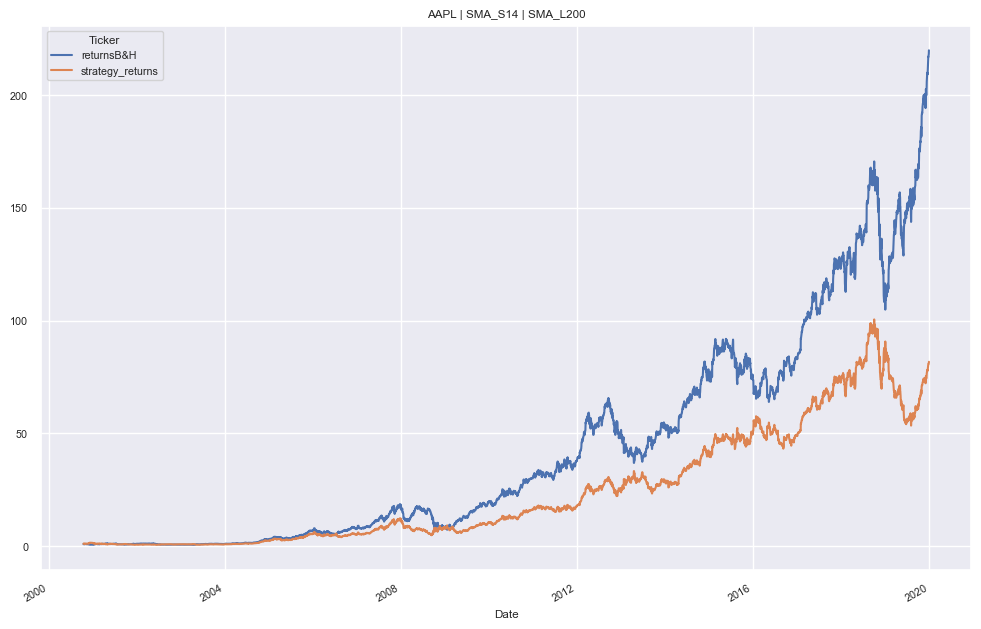

In [40]:
test.test_results()
test.plot_results()
plt.show()

In [41]:
spy = yf.download('spy','2024-07-21', '2025-02-07')

[*********************100%***********************]  1 of 1 completed


In [42]:
spyc=spy.Close.copy()

In [43]:
spyc['ret']=np.log(spyc.pct_change()+1)

In [44]:
spyc.dropna(inplace=True)

In [45]:
spyc["cumret"]=spyc.ret.cumsum().apply(np.exp)

In [46]:
MBLY = yf.download('MBLY')

[*********************100%***********************]  1 of 1 completed


In [47]:
mbly = MBLY.Close.copy()

In [48]:
mbly['d_returns']=np.log(mbly.pct_change()+1)

<Axes: ylabel='Frequency'>

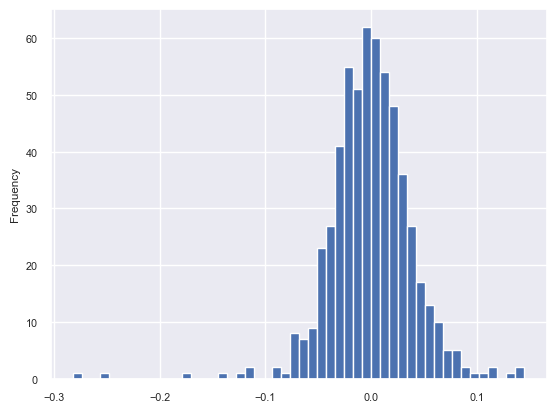

In [49]:
mbly['d_returns'].plot(kind='hist',bins=50)

In [171]:
def sma_returns(stock,x,y):
    df=yf.download(stock)
    data = df.Close.copy()
    data['d_returns']=np.log(data.pct_change()+1)
    data["SMA{}".format(x)]=data[stock].rolling(window=x).mean()
    data["SMA{}".format(y)]=data[stock].rolling(window=y).mean()
    data['position']=np.where(data["SMA{}".format(x)]>data["SMA{}".format(y)], 1,-1)
    data["strategy"]= data['d_returns']*data.position.shift(1)
    data['SR']=data['strategy'].rolling(window=252).mean()/data['strategy'].rolling(window=252).std() * np.sqrt(252)
    data.dropna(inplace= True)
    return data

In [397]:
#Sharpe ratio for one stock
def SR_return(stock):
    df=yf.download(stock)
    data = df.Close.copy()
    data['d_returns']=np.log(data.pct_change()+1)
    data['SR']=data['d_returns'].rolling(window=252).mean()/data['d_returns'].rolling(window=252).std() * np.sqrt(252)
    data.dropna(inplace= True)
    return data

In [399]:
def t_test(data):
    # two sigma threshold test
    plt.plot(data.index, data.SR, label='SR')
    plt.plot(data.index, (data.SR - 2 * data.SR.std()), label='Lower Bound', linestyle='--')
    plt.plot(data.index,( data.SR + 2 * data.SR.std()), label='Upper Bound', linestyle='--')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.show()

In [395]:
#Sharpe ratio for many stocks
def SR_returns(stocks, start, end):
    df=yf.download(stocks, start = start, end =end )
    data = df.Close
    returns =np.log(data.pct_change()+1)
    SR =returns.rolling(window=21).mean()/returns.rolling(window=21).std() * np.sqrt(21)
    SR.dropna(inplace= True)
    return SR

[*********************100%***********************]  1 of 1 completed


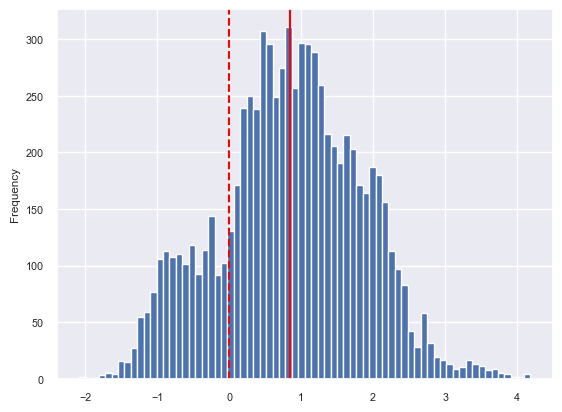

In [52]:
uvix = d_returns('SPY')
uvix['SR'].plot(kind='hist',bins=70)
plt.axvline(x=0, color='red', linestyle='--')  # Add a vertical line at x=0
plt.axvline(x=uvix.SR.mean(), color='red', linestyle='-')  # Add a vertical line at x=0
plt.show()

[*********************100%***********************]  1 of 1 completed


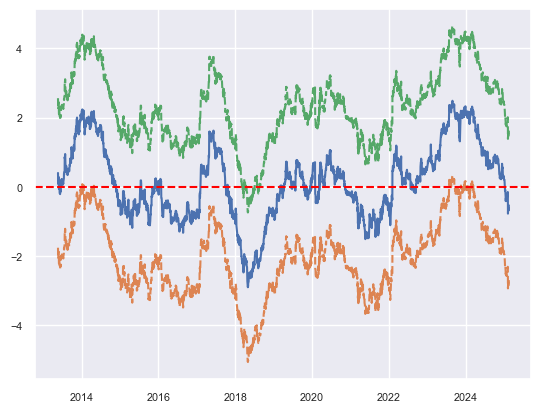

In [199]:
a=sma_returns('META' ,3 , 30)
two_sigma_test(a)

[*********************100%***********************]  1 of 1 completed


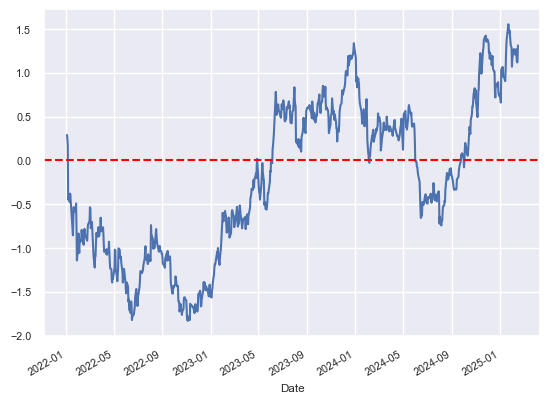

In [53]:
v = d_returns('SOFI')
v.SR.plot()
plt.axhline(y=0, color='red', linestyle='--') #horizontal line
plt.show()

In [55]:
v.SR.std()

0.8768755580775682

In [415]:
x = sma_returns ('HIMS', 14,50)
x.SR.mean()

[*********************100%***********************]  1 of 1 completed


0.6095083945502002

In [535]:
def covariance(x,y,start,end):
    ticker = [x,y]
    df = yf.download(ticker,start=start,end=end)
    data = df.Close.copy()
    returns_x = np.log(data[x].pct_change() + 1).dropna() #Select the column x and calculate returns
    returns_y = np.log(data[y].pct_change() + 1).dropna() #Select the column y and calculate returns
    # Calculate the covariance between the two return series
    covariance_xy = returns_x.cov(returns_y)

    return covariance_xy

In [537]:
covariance('AMD','NVDA','2020-01-01','2025-01-01')

[*********************100%***********************]  2 of 2 completed


0.0008350681621585878